# Resumos e um pouco de Visualização no pandas


## Resumo

Vamos ver alguns métodos para analisar nossas tabelas (dataframes)

Além disso, vamos usar os plot de gráfico padrões do pandas, mas no projeto de DataScience veremos outras mais bonitas e também muito práticas.

OBS: O pandas usa o matplotlib (que vimos na seção de "módulos e bibliotecas") para plotar gráficos.<br>
Se quiser personalizar mais do que o padrão do pandas, importe o matplotlib e use os métodos do matplotlib

- Preparando as bases de dados (o que fizemos na última aula)

In [14]:
import pandas as pd
#importando os arquivos
vendas_df = pd.read_csv(r'C:\Users\joa_o\OneDrive\GitHub\Python-projects\python_impressionador\Pandas\Contoso - Vendas - 2017.csv', sep=';')
produtos_df = pd.read_csv(r'C:\Users\joa_o\OneDrive\GitHub\Python-projects\python_impressionador\Pandas\Contoso - Cadastro Produtos.csv', encoding = 'latin-1', sep=';').rename(columns={'ÿNome do Produto' : 'Nome do Produto'})
lojas_df = pd.read_csv(r'C:\Users\joa_o\OneDrive\GitHub\Python-projects\python_impressionador\Pandas\Contoso - Lojas.csv',encoding = 'latin-1', sep=';')
clientes_df = pd.read_csv(r'C:\Users\joa_o\OneDrive\GitHub\Python-projects\python_impressionador\Pandas\Contoso - Clientes.csv', encoding = 'latin-1', sep=';').rename(columns={'ÿID Cliente' : 'ID Cliente'}) #Corrigindo o nome da coluna ID Cliente...



#limpando apenas as colunas que queremos
clientes_df = clientes_df[['ID Cliente', 'E-mail']]
produtos_df = produtos_df[['ID Produto', 'Nome do Produto']]
lojas_df = lojas_df[['ID Loja', 'Nome da Loja']]

#mesclando e renomeando os dataframes
vendas_df = vendas_df.merge(produtos_df, on='ID Produto')
vendas_df = vendas_df.merge(lojas_df, on='ID Loja')
vendas_df = vendas_df.merge(clientes_df, on='ID Cliente').rename(columns={'E-mail': 'E-mail do Cliente'})
display(vendas_df)

,Numero da Venda,Data da Venda,Data do Envio,ID Canal,ID Loja,ID Produto,ID Promocao,ID Cliente,Quantidade Vendida,Quantidade Devolvida,Nome do Produto,Nome da Loja,E-mail do Cliente
0,1,01/01/2017,02/01/2017,1,86,981,2,6825,9,1,A. Datum Advanced Digital Camera M300 Pink,Loja Contoso Austin,rbrumfieldmy@ameblo.jp
1,2,01/01/2017,06/01/2017,5,308,1586,2,18469,9,1,SV DVD 55DVD Storage Binder M56 Black,Loja Contoso North America Reseller,cshawd4@technorati.com
2,3,01/01/2017,01/01/2017,0,294,1444,5,19730,13,1,"The Phone Company Touch Screen Phones 26-2.2"" ...",Loja Contoso Tehran No.2,kgorriekd@bandcamp.com
3,4,01/01/2017,01/01/2017,0,251,1468,5,29326,6,1,Contoso Touch Screen Phones - CRT M11 Black,Loja Contoso Singapore,angela49@adventure-works.com
4,5,01/01/2017,07/01/2017,6,94,1106,2,22617,4,1,Contoso SLR Camera M146 Orange,Loja Contoso Grand Prairie,jacob4@adventure-works.com
...,...,...,...,...,...,...,...,...,...,...,...,...,...
980637,980638,31/12/2017,31/12/2017,0,194,2490,4,10353,120,0,Contoso Rubberized Skin BlackBerry E100 White,Loja Contoso Ridgely,ocrosson9u@illinois.edu
980638,980639,31/12/2017,06/01/2018,6,32,2488,4,31750,120,0,Contoso Rubberized Skin BlackBerry E100 Black,Loja Contoso Milliken,victor11@adventure-works.com
980639,980640,31/12/2017,03/01/2018,3,210,2511,10,12003,80,0,Contoso Original K1m Li-Ion Standard Battery E...,Loja Contoso Cheshire,mtopaz4@gmpg.org
980640,980641,31/12/2017,31/12/2017,0,53,436,4,25550,39,0,Adventure Works Desktop PC1.80 ED180 White,Loja Contoso East Troy,lance5@adventure-works.com


### Qual cliente que comprou mais vezes?

- Usaremos o método .value_counts() para contar quantas vezes cada valor do Dataframe aparece
- Usaremos o método .plot() para exibir um gráfico

E-mail do Cliente
karen33@adventure-works.com    77
chloe77@adventure-works.com    74
julia43@adventure-works.com    69
josé64@adventure-works.com     68
karen16@adventure-works.com    68
                               ..
hcadwalladergx@slashdot.org     1
ian86@adventure-works.com       1
cvernazza4k@wordpress.com       1
rpeadena0@delicious.com         1
ppitman73@goodreads.com         1
Name: count, Length: 38907, dtype: int64

<Axes: xlabel='E-mail do Cliente'>

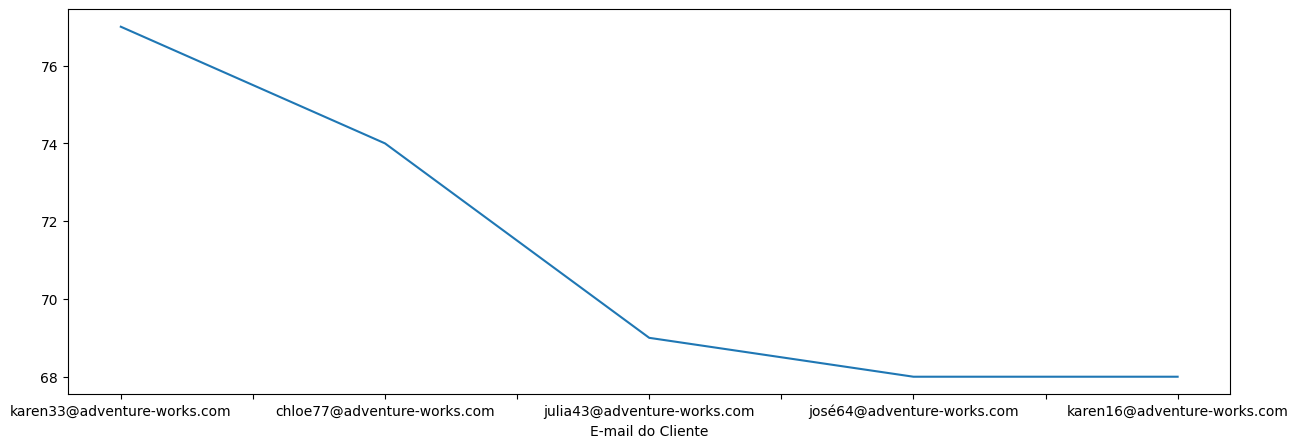

In [30]:
import matplotlib.pyplot as plt
frequencia_compra_cliente = vendas_df['E-mail do Cliente'].value_counts()
display(frequencia_compra_cliente)
frequencia_compra_cliente[:5].plot(figsize=(15, 5))

### Qual a Loja que mais vendeu?

- Usaremos o .groupby para agrupar o nosso dataframe, de acordo com o que queremos (somando as quantidades de vendas, por exemplo)

In [34]:
vendas_lojas = vendas_df.groupby('Nome da Loja').sum()
vendas_lojas = vendas_lojas[['Quantidade Vendida']]
display(vendas_lojas)

,Quantidade Vendida
Nome da Loja,
Loja Contoso Albany,26353
Loja Contoso Alexandria,26247
Loja Contoso Amsterdam,28294
Loja Contoso Anchorage,27451
Loja Contoso Annapolis,26065
...,...
Loja Contoso Yokohama,28023
Loja Contoso York,27164
Loja Contoso koln No.1,29046


<Axes: xlabel='Nome da Loja'>

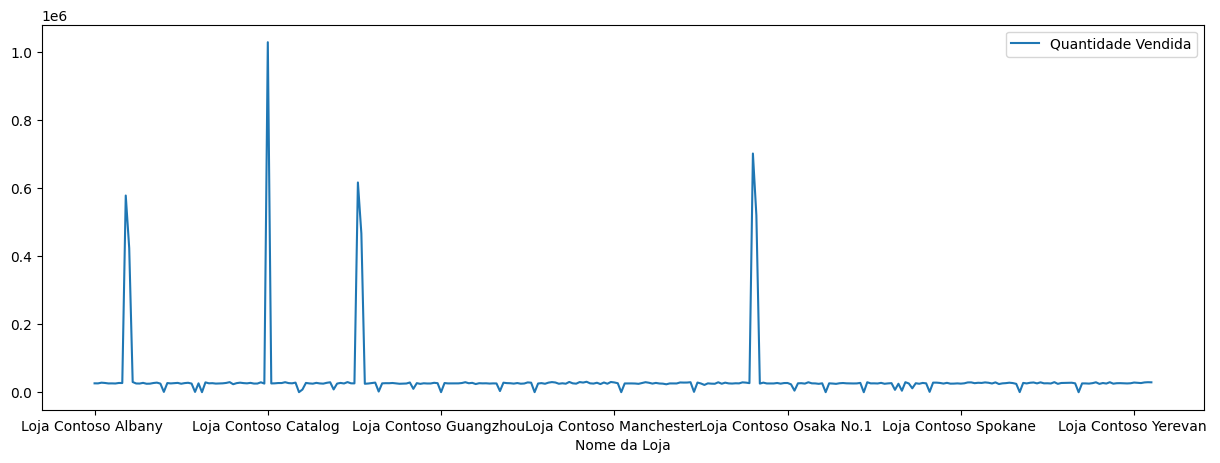

In [ ]:
vendas_lojas[:5].plot(figsize=(15, 5))

- Agora precisamos pegar o maior valor. Temos 2 formas:
    1. Ordenar o dataframe em ordem decrescente de Quantidade Vendida
        - Método .sort_values
    2. Pegar o Maior valor diretamente
        - Métodos .max() e .idxmax()

<Axes: xlabel='Nome da Loja'>

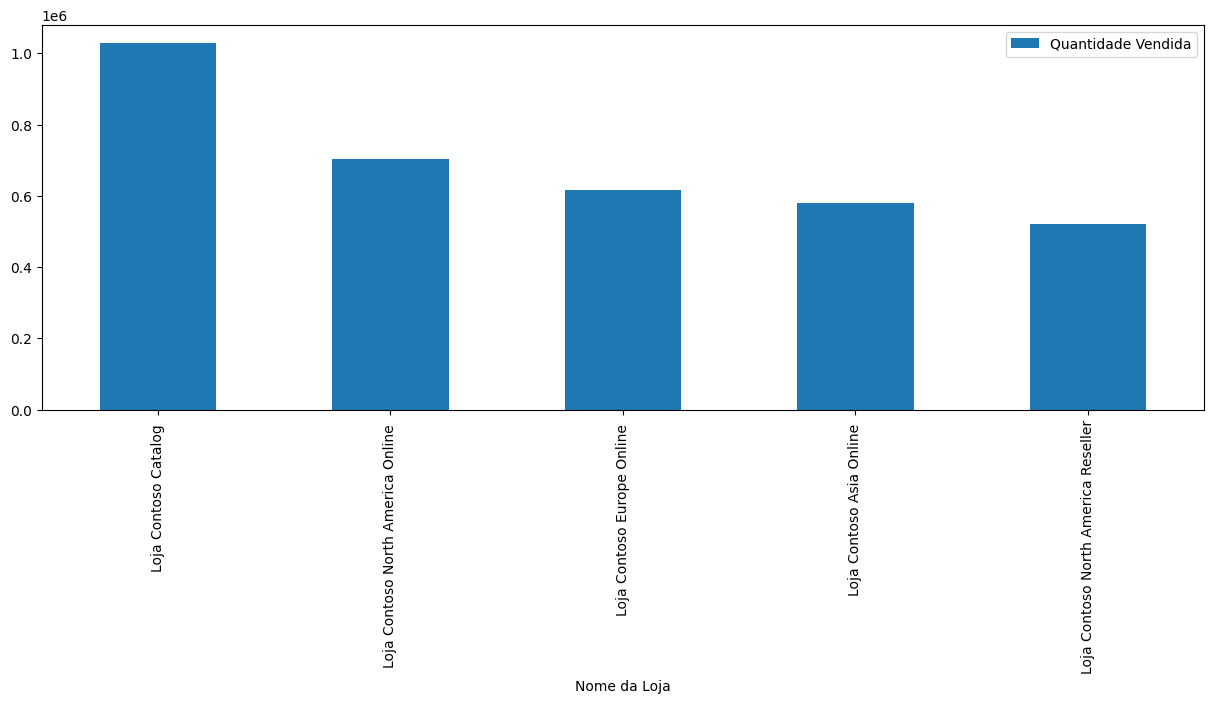

In [39]:
vendas_lojas = vendas_lojas.sort_values('Quantidade Vendida', ascending=False)
vendas_lojas[:5].plot(figsize=(15, 5), kind='bar')

In [44]:
#pegando o maior valor e se índice
mais_vendas = vendas_lojas['Quantidade Vendida'].max()
melhor_loja = vendas_lojas['Quantidade Vendida'].idxmax()

print(f'{melhor_loja} vendeu: {mais_vendas} unidades')

Loja Contoso Catalog  vendeu: 1029117 unidades


### Qual produto que menos vendeu?

- Já temos uma lista criada para isso, basta verificarmos o final da lista (já que ela está ordenada) ou então usarmos os métodos:
    1. min()
    2. idxmin()

In [48]:
import time

inicio = time.time()
vendas_produtos = vendas_df.groupby('Nome do Produto').sum()
vendas_produtos = vendas_produtos[['Quantidade Vendida']]
display(vendas_produtos)
prod_menos_vendido = vendas_produtos['Quantidade Vendida'].idxmin()
menor_qtd_vendas = vendas_produtos['Quantidade Vendida'].min()
fim = time.time()
tempo = fim - inicio
print(f'O produto menos vendido, foi: {prod_menos_vendido}, com: {menor_qtd_vendas} unidades vendidas.')
print(f'{tempo:.2f}')

,Quantidade Vendida
Nome do Produto,
A. Datum Advanced Digital Camera M300 Azure,8999
A. Datum Advanced Digital Camera M300 Black,12087
A. Datum Advanced Digital Camera M300 Green,11400
A. Datum Advanced Digital Camera M300 Grey,10713
A. Datum Advanced Digital Camera M300 Orange,12181
...,...
WWI Stereo Bluetooth Headphones E1000 Black,4909
WWI Stereo Bluetooth Headphones E1000 Blue,4374
WWI Stereo Bluetooth Headphones E1000 Green,4511


O produto menos vendido, foi: SV 16xDVD E340 Silver, com: 86 unidades vendidas.
7.19
